In [1]:
# Bangla ELECTRA Fine-tuning for Multi-label Cyberbullying Detection

# Install Required Packages and Setup Google Drive

!pip install -q transformers datasets torch scikit-learn pandas numpy matplotlib seaborn

# Mount Google Drive for automatic saving
from google.colab import drive
drive.mount('/content/drive')

print("All packages installed successfully!")
print("Google Drive mounted successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.0 MB/s eta 0:00:00
Mounted at /content/drive
All packages installed successfully!
Google Drive mounted successfully!


In [2]:
# Import all the libraries and setup project configuration
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    ElectraTokenizer,
    ElectraModel,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import os
import json
import shutil
from datetime import datetime

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Project Configuration
PROJECT_CONFIG = {
    'model_name': 'bangla-electra',
    'model_path': 'monsoon-nlp/bangla-electra',
    'project_name': 'Bangla-ELECTRA-Cyberbullying',
    'experiment_date': datetime.now().strftime("%Y%m%d_%H%M%S"),
    'num_folds': 5,
    'momentum': 0.9,
    'dropout': 0.1,
    'max_length': 128
}

# Google Drive Setup
DRIVE_BASE_PATH = '/content/drive/MyDrive'
PROJECT_DRIVE_PATH = f"{DRIVE_BASE_PATH}/{PROJECT_CONFIG['project_name']}"

# Create project directory structure in Google Drive
def setup_drive_directories():
    """Create necessary directories in Google Drive for the project"""
    directories = [
        PROJECT_DRIVE_PATH,
        f"{PROJECT_DRIVE_PATH}/experiments",
    ]

    for directory in directories:
        os.makedirs(directory, exist_ok=True)
        print(f"Created/verified directory: {directory}")

setup_drive_directories()

# Session directory for current experiment
SESSION_ID = f"{PROJECT_CONFIG['model_name']}_{PROJECT_CONFIG['experiment_date']}"
SESSION_DRIVE_PATH = f"{PROJECT_DRIVE_PATH}/experiments/{SESSION_ID}"
os.makedirs(SESSION_DRIVE_PATH, exist_ok=True)

print(f"Session directory: {SESSION_DRIVE_PATH}")

# Save project configuration
config_file = f"{SESSION_DRIVE_PATH}/project_config.json"
with open(config_file, 'w') as f:
    json.dump(PROJECT_CONFIG, f, indent=2)

print(f"Project configuration saved to: {config_file}")

Created/verified directory: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying
Created/verified directory: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments
Session directory: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748
Project configuration saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/project_config.json


In [4]:
# Load dataset and automatically backup to Google Drive

from google.colab import files

print("Please upload your dataset file:")
uploaded = files.upload()

# Get the filename of the uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Backup original dataset to Google Drive
dataset_backup_path = f"{SESSION_DRIVE_PATH}/original_dataset.csv"
df.to_csv(dataset_backup_path, index=False)
print(f"Dataset backed up to: {dataset_backup_path}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Generate and save dataset report
dataset_report = {
    'shape': df.shape,
    'columns': df.columns.tolist(),
    'missing_values': df.isnull().sum().to_dict(),
    'data_types': df.dtypes.to_dict(),
    'memory_usage': df.memory_usage(deep=True).sum()
}

report_file = f"{SESSION_DRIVE_PATH}/dataset_report.json"
with open(report_file, 'w') as f:
    json.dump(dataset_report, f, indent=2, default=str)

print(f"Dataset report saved to: {report_file}")

Please upload your dataset file:


Saving 1_Multilablel_Cyberbully_Data.csv to 1_Multilablel_Cyberbully_Data.csv
Dataset loaded successfully!
Dataset shape: (12546, 8)
Columns: ['Gender', 'Profession', 'comment', 'bully', 'sexual', 'religious', 'threat', 'spam']
Dataset backed up to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/original_dataset.csv

First 5 rows of the dataset:
   Gender Profession                                            comment  \
0  female     dancer                              এই দেশে এইসব কি হচ্ছে   
1  female     dancer                                        মানে কি বলব   
2  female     dancer                                ভাই ভিডিও ফুল প্লিজ   
3  female     dancer  নিজের খরচ নিজেই চালাতে পারবেন এমন ভালো একটা জব...   
4  female     dancer                  ভিডিও কলে রেগুলার কাজ করতে পারবেন   

   bully  sexual  religious  threat  spam  
0      0       0          0       0     0  
1      0       0          0       0     0  
2      0       1     

In [5]:
# Clean and prepare the dataset for training

print("Preprocessing the dataset...")

# Drop gender and profession columns as mentioned
df_clean = df.drop(['Gender', 'Profession'], axis=1)
print(f"Dropped Gender and Profession columns. New shape: {df_clean.shape}")

# Check for missing values
missing_values_report = df_clean.isnull().sum()
print(f"\nMissing values check:")
print(missing_values_report)

# Display label distribution
label_columns = ['bully', 'sexual', 'religious', 'threat', 'spam']
label_distribution = {}

print(f"\nLabel distribution:")
for label in label_columns:
    positive_count = df_clean[label].sum()
    percentage = positive_count/len(df_clean)*100
    label_distribution[label] = {
        'positive_samples': int(positive_count),
        'percentage': float(percentage)
    }
    print(f"{label}: {positive_count} positive samples ({percentage:.2f}%)")

# Save preprocessing report
preprocessing_report = {
    'original_shape': df.shape,
    'cleaned_shape': df_clean.shape,
    'dropped_columns': ['Gender', 'Profession'],
    'label_columns': label_columns,
    'label_distribution': label_distribution,
    'missing_values': missing_values_report.to_dict()
}

preprocessing_file = f"{SESSION_DRIVE_PATH}/preprocessing_report.json"
with open(preprocessing_file, 'w') as f:
    json.dump(preprocessing_report, f, indent=2, default=str)

# Save cleaned dataset
cleaned_dataset_path = f"{SESSION_DRIVE_PATH}/cleaned_dataset.csv"
df_clean.to_csv(cleaned_dataset_path, index=False)

print(f"Preprocessing report saved to: {preprocessing_file}")
print(f"Cleaned dataset saved to: {cleaned_dataset_path}")

# Show some sample comments and their labels
print(f"\nSample comments with labels:")
for i in range(3):
    comment = df_clean.iloc[i]['comment']
    labels = [df_clean.iloc[i][col] for col in label_columns]
    print(f"Comment: {comment}")
    print(f"Labels: {dict(zip(label_columns, labels))}")
    print("-" * 50)

Preprocessing the dataset...
Dropped Gender and Profession columns. New shape: (12546, 6)

Missing values check:
comment      0
bully        0
sexual       0
religious    0
threat       0
spam         0
dtype: int64

Label distribution:
bully: 8052 positive samples (64.18%)
sexual: 2059 positive samples (16.41%)
religious: 1607 positive samples (12.81%)
threat: 1422 positive samples (11.33%)
spam: 1089 positive samples (8.68%)
Preprocessing report saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/preprocessing_report.json
Cleaned dataset saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/cleaned_dataset.csv

Sample comments with labels:
Comment: এই দেশে এইসব কি হচ্ছে
Labels: {'bully': np.int64(0), 'sexual': np.int64(0), 'religious': np.int64(0), 'threat': np.int64(0), 'spam': np.int64(0)}
--------------------------------------------------
Comment: মানে কি বলব
Labels: {'bully': n

In [6]:
# Create a custom dataset class for our multi-label classification task

class CyberbullyingDataset(Dataset):
    """
    Custom Dataset class for loading cyberbullying data

    1. Load comments and labels in batches
    2. Tokenize text using ELECTRA tokenizer
    3. Convert labels to tensors
    """

    def __init__(self, comments, labels, tokenizer, max_length=128):
        """
        Initialize the dataset

        Args:
            comments: List of text comments
            labels: List of label arrays (multi-label)
            tokenizer: ELECTRA tokenizer
            max_length: Maximum sequence length for tokenization
        """
        self.comments = comments
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """Return the total number of samples"""
        return len(self.comments)

    def __getitem__(self, idx):
        """
        Get a single sample from the dataset

        This method:
        1. Takes a comment and tokenizes it
        2. Converts labels to tensor format
        3. Returns the processed data
        """
        comment = str(self.comments[idx])
        labels = self.labels[idx]

        # Tokenize the comment
        encoding = self.tokenizer(
            comment,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.float)
        }

print("Custom Dataset class created successfully!")

Custom Dataset class created successfully!


In [7]:
# Create our multi-label classification model

from transformers import ElectraModel

class ElectraMultiLabelClassifier(nn.Module):
    """
    Multi-label classifier based on ELECTRA

    This model:
    1. Uses pre-trained Bangla ELECTRA as base
    2. Adds a custom classification head for 5 labels
    3. Uses pooling to get sentence-level representation
    """

    def __init__(self, model_name, num_labels):
        super(ElectraMultiLabelClassifier, self).__init__()

        # Load pre-trained ELECTRA model (base model without classification head)
        self.electra = ElectraModel.from_pretrained(model_name)

        # Custom classification head for multi-label classification
        self.classifier = nn.Sequential(
            nn.Linear(self.electra.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask):
        """
        Forward pass through the model

        Args:
            input_ids: Tokenized input sequences
            attention_mask: Attention masks for input

        Returns:
            Logits for each label (batch_size, num_labels)
        """
        # Get ELECTRA outputs
        outputs = self.electra(input_ids=input_ids, attention_mask=attention_mask)

        # Get the [CLS] token representation (first token)
        # This represents the entire sequence
        cls_output = outputs.last_hidden_state[:, 0, :]  # Shape: (batch_size, hidden_size)

        # Pass through classification head
        logits = self.classifier(cls_output)  # Shape: (batch_size, num_labels)

        return logits

print("Multi-label ELECTRA classifier created!")

Multi-label ELECTRA classifier created!


In [8]:
# Training functions with automatic saving capabilities

def calculate_metrics(y_true, y_pred):
    """Calculate evaluation metrics for multi-label classification"""
    # Convert probabilities to binary predictions (threshold = 0.5)
    y_pred_binary = (y_pred > 0.5).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred_binary)
    precision = precision_score(y_true, y_pred_binary, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred_binary, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred_binary, average='weighted', zero_division=0)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Train the model for one epoch"""
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc='Training')

    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids, attention_mask)

        # Calculate loss using Binary Cross Entropy (good for multi-label)
        loss_fn = nn.BCEWithLogitsLoss()
        loss = loss_fn(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader)

def evaluate_model(model, dataloader, device):
    """Evaluate the model on validation/test data"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Evaluating')

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids, attention_mask)

            # Calculate loss
            loss_fn = nn.BCEWithLogitsLoss()
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            # Apply sigmoid to get probabilities
            predictions = torch.sigmoid(outputs)

            # Store predictions and labels
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    avg_loss = total_loss / len(dataloader)
    metrics = calculate_metrics(np.array(all_labels), np.array(all_predictions))
    metrics['loss'] = avg_loss

    return metrics

def save_session_data(results_df, session_info, force_save=False):
    """
    Save current session data to Google Drive

    Args:
        results_df: DataFrame with experiment results
        session_info: Dictionary with session information
        force_save: Force save even if no new results
    """
    try:
        # Save results
        results_file = f"{SESSION_DRIVE_PATH}/results.csv"
        results_df.to_csv(results_file, index=False)

        # Save session info
        session_file = f"{SESSION_DRIVE_PATH}/session_info.json"
        with open(session_file, 'w') as f:
            json.dump(session_info, f, indent=2, default=str)

        # Create backup with timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        backup_results = f"{SESSION_DRIVE_PATH}/backup_results_{timestamp}.csv"
        results_df.to_csv(backup_results, index=False)

        print(f"Session data saved to Google Drive:")
        print(f"   - Results: {results_file}")
        print(f"   - Session Info: {session_file}")
        print(f"   - Backup: {backup_results}")

        return True
    except Exception as e:
        print(f"Error saving session data: {str(e)}")
        return False

print("Enhanced training functions with auto-save created!")

Enhanced training functions with auto-save created!


In [5]:
# Define the hyperparameter combinations to test

# Hyperparameter combinations from your table
experiment_configs = [
    # Batch size 16 experiments
    {'batch_size': 16, 'learning_rate': 0.01, 'num_epochs': 10},
    {'batch_size': 16, 'learning_rate': 0.01, 'num_epochs': 20},
    {'batch_size': 16, 'learning_rate': 0.01, 'num_epochs': 30},

    # Batch size 32 experiments
    {'batch_size': 32, 'learning_rate': 0.01, 'num_epochs': 10},
    {'batch_size': 32, 'learning_rate': 0.01, 'num_epochs': 20},
    {'batch_size': 32, 'learning_rate': 0.01, 'num_epochs': 30},

    # Batch size 64 experiments
    {'batch_size': 64, 'learning_rate': 0.01, 'num_epochs': 10},
    {'batch_size': 64, 'learning_rate': 0.01, 'num_epochs': 20},
    {'batch_size': 64, 'learning_rate': 0.01, 'num_epochs': 30},
]

print(f"Set up {len(experiment_configs)} experiment configurations")

# Save experiment configurations to Drive
configs_file = f"{SESSION_DRIVE_PATH}/experiment_configurations.json"
with open(configs_file, 'w') as f:
    json.dump(experiment_configs, f, indent=2)
print(f"Experiment configurations saved to: {configs_file}")

Set up 9 experiment configurations
Experiment configurations saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250816_162112/experiment_configurations.json


In [10]:
# =============================================================================
# CELL 9: Data Preparation with Drive Save (Enhanced)
# =============================================================================
# Prepare the data for cross-validation experiments

print("Preparing data for experiments...")

# Extract features and labels
comments = df_clean['comment'].values
labels = df_clean[label_columns].values

print(f"Prepared {len(comments)} comments with {len(label_columns)} labels each")

# Initialize tokenizer
MODEL_NAME = PROJECT_CONFIG['model_path']
tokenizer = ElectraTokenizer.from_pretrained(MODEL_NAME)

print(f"Loaded tokenizer for {MODEL_NAME}")

# Create results storage
results_df = pd.DataFrame(columns=[
    'Batch_size', 'Learning_rate', 'Num_epochs', 'Num_folds', 'Momentum',
    'Dropout', 'Accuracy', 'Precision', 'Recall', 'F1_Score'
])

# Initialize session info
session_info = {
    'session_id': SESSION_ID,
    'model_name': PROJECT_CONFIG['model_name'],
    'model_path': PROJECT_CONFIG['model_path'],
    'start_time': datetime.now().isoformat(),
    'total_experiments': len(experiment_configs),
    'completed_experiments': 0,
    'current_status': 'initialized',
    'dataset_info': {
        'num_samples': len(comments),
        'num_labels': len(label_columns),
        'label_columns': label_columns
    }
}

# Save initial session data
save_session_data(results_df, session_info, force_save=True)

print("Ready to start experiments!")

Preparing data for experiments...
Prepared 12546 comments with 5 labels each


tokenizer_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/391 [00:00<?, ?B/s]

Loaded tokenizer for monsoon-nlp/bangla-electra
Session data saved to Google Drive:
   - Results: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/results.csv
   - Session Info: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/session_info.json
   - Backup: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/backup_results_20250817_122827.csv
Ready to start experiments!


In [11]:
# Run experiments with comprehensive saving and resume capability

def create_experiment_id(config):
    """Create unique ID for each experiment configuration"""
    return f"B{config['batch_size']}_LR{config['learning_rate']}_E{config['num_epochs']}"

def run_single_experiment(config, comments, labels, tokenizer, device, exp_number, total_experiments):
    """Run a single experiment configuration with k-fold cross-validation"""
    exp_id = create_experiment_id(config)
    print(f"\nRunning experiment {exp_number}/{total_experiments}: {exp_id}")
    print(f"   Batch Size={config['batch_size']}, LR={config['learning_rate']}, Epochs={config['num_epochs']}")

    # Create experiment-specific directory
    exp_dir = f"{SESSION_DRIVE_PATH}/individual_experiments/{exp_id}"
    os.makedirs(exp_dir, exist_ok=True)

    # Initialize k-fold cross-validation
    kfold = KFold(n_splits=PROJECT_CONFIG['num_folds'], shuffle=True, random_state=42)

    fold_results = []
    experiment_log = {
        'experiment_id': exp_id,
        'config': config,
        'start_time': datetime.now().isoformat(),
        'folds': []
    }

    for fold, (train_idx, val_idx) in enumerate(kfold.split(comments)):
        fold_start_time = datetime.now()
        print(f"Fold {fold + 1}/{PROJECT_CONFIG['num_folds']}")

        # Split data
        train_comments = comments[train_idx]
        train_labels = labels[train_idx]
        val_comments = comments[val_idx]
        val_labels = labels[val_idx]

        # Create datasets
        train_dataset = CyberbullyingDataset(train_comments, train_labels, tokenizer, PROJECT_CONFIG['max_length'])
        val_dataset = CyberbullyingDataset(val_comments, val_labels, tokenizer, PROJECT_CONFIG['max_length'])

        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)

        # Initialize model
        model = ElectraMultiLabelClassifier(MODEL_NAME, len(label_columns))
        model.to(device)

        # Initialize optimizer and scheduler
        optimizer = AdamW(model.parameters(), lr=config['learning_rate'])
        total_steps = len(train_loader) * config['num_epochs']
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=0,
            num_training_steps=total_steps
        )

        # Training loop
        best_f1 = 0
        epoch_history = []

        for epoch in range(config['num_epochs']):
            train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
            val_metrics = evaluate_model(model, val_loader, device)

            epoch_data = {
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'val_metrics': val_metrics
            }
            epoch_history.append(epoch_data)

            if val_metrics['f1'] > best_f1:
                best_f1 = val_metrics['f1']
                best_metrics = val_metrics.copy()

                # Save best model for this fold
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'config': config,
                    'fold': fold,
                    'epoch': epoch + 1,
                    'metrics': best_metrics
                }, f"{exp_dir}/best_model_fold_{fold}.pth")

        fold_duration = (datetime.now() - fold_start_time).total_seconds()

        fold_info = {
            'fold': fold,
            'duration_seconds': fold_duration,
            'best_metrics': best_metrics,
            'epoch_history': epoch_history
        }
        experiment_log['folds'].append(fold_info)

        fold_results.append(best_metrics)
        print(f"Fold {fold + 1} completed. Best F1: {best_f1:.4f} (Duration: {fold_duration:.1f}s)")

    # Calculate average metrics across folds
    avg_metrics = {}
    for key in fold_results[0].keys():
        if key != 'loss':  # Don't average loss
            avg_metrics[key] = np.mean([result[key] for result in fold_results])

    # Complete experiment log
    experiment_log['end_time'] = datetime.now().isoformat()
    experiment_log['duration_seconds'] = (datetime.now() - datetime.fromisoformat(experiment_log['start_time'])).total_seconds()
    experiment_log['avg_metrics'] = avg_metrics
    experiment_log['std_metrics'] = {key: np.std([result[key] for result in fold_results]) for key in avg_metrics.keys()}

    # Save experiment log
    log_file = f"{exp_dir}/experiment_log.json"
    with open(log_file, 'w') as f:
        json.dump(experiment_log, f, indent=2, default=str)

    return avg_metrics

# Load existing results if available
RESULTS_FILE = f"{SESSION_DRIVE_PATH}/results.csv"
if os.path.exists(RESULTS_FILE):
    print(f"Loading existing results from {RESULTS_FILE}")
    results_df = pd.read_csv(RESULTS_FILE)
    completed_experiments = set()
    for _, row in results_df.iterrows():
        exp_id = f"B{int(row['Batch_size'])}_LR{row['Learning_rate']}_E{int(row['Num_epochs'])}"
        completed_experiments.add(exp_id)
    print(f"Found {len(completed_experiments)} completed experiments")
else:
    print("No existing results found. Starting fresh.")
    results_df = pd.DataFrame(columns=[
        'Batch_size', 'Learning_rate', 'Num_epochs', 'Num_folds', 'Momentum',
        'Dropout', 'Accuracy', 'Precision', 'Recall', 'F1_Score'
    ])
    completed_experiments = set()

# Filter out completed experiments
remaining_configs = []
for config in experiment_configs:
    exp_id = create_experiment_id(config)
    if exp_id not in completed_experiments:
        remaining_configs.append(config)

print(f"Total experiments: {len(experiment_configs)}")
print(f"Completed experiments: {len(completed_experiments)}")
print(f"Remaining experiments: {len(remaining_configs)}")

# Set how many experiments to run in this session
MAX_EXPERIMENTS_PER_SESSION = 4  # Adjust this based on your time limit
experiments_to_run = remaining_configs[:MAX_EXPERIMENTS_PER_SESSION]

print(f"Running {len(experiments_to_run)} experiments in this session:")
for i, config in enumerate(experiments_to_run):
    exp_id = create_experiment_id(config)
    print(f"  {i+1}. {exp_id}")

# Update session info
session_info.update({
    'current_status': 'running',
    'experiments_this_session': len(experiments_to_run),
    'session_start_time': datetime.now().isoformat()
})

# Run experiments with enhanced saving
session_results = []
start_time = datetime.now()

for i, config in enumerate(experiments_to_run):
    try:
        exp_id = create_experiment_id(config)
        print(f"\n{'='*60}")
        print(f"Session Progress: {i+1}/{len(experiments_to_run)}")
        print(f"Elapsed time: {datetime.now() - start_time}")
        print(f"Experiment ID: {exp_id}")

        # Run experiment
        avg_metrics = run_single_experiment(
            config, comments, labels, tokenizer, device,
            len(results_df) + i + 1, len(experiment_configs)
        )

        # Store results
        result_row = {
            'Batch_size': config['batch_size'],
            'Learning_rate': config['learning_rate'],
            'Num_epochs': config['num_epochs'],
            'Num_folds': PROJECT_CONFIG['num_folds'],
            'Momentum': PROJECT_CONFIG['momentum'],
            'Dropout': PROJECT_CONFIG['dropout'],
            'Accuracy': avg_metrics['accuracy'],
            'Precision': avg_metrics['precision'],
            'Recall': avg_metrics['recall'],
            'F1_Score': avg_metrics['f1']
        }

        # Add to results dataframe
        results_df = pd.concat([results_df, pd.DataFrame([result_row])], ignore_index=True)
        session_results.append(result_row)

        # Update session info
        session_info['completed_experiments'] = len(results_df)
        session_info['last_completed_experiment'] = exp_id
        session_info['last_update'] = datetime.now().isoformat()

        # Save results immediately after each experiment
        save_session_data(results_df, session_info)

        print(f"Experiment {exp_id} completed successfully!")
        print(f"   Results: Acc={avg_metrics['accuracy']:.4f}, "
              f"Prec={avg_metrics['precision']:.4f}, "
              f"Rec={avg_metrics['recall']:.4f}, "
              f"F1={avg_metrics['f1']:.4f}")
        print(f"Results automatically saved to Google Drive")

    except Exception as e:
        print(f"Experiment {exp_id} failed: {str(e)}")
        # Save error info
        error_dir = f"{SESSION_DRIVE_PATH}/errors"
        os.makedirs(error_dir, exist_ok=True)

        error_info = {
            'experiment_id': exp_id,
            'error': str(e),
            'time': datetime.now().isoformat(),
            'config': config
        }

        with open(f'{error_dir}/error_{exp_id}.json', 'w') as f:
            json.dump(error_info, f, indent=2)
        continue

# Final session summary
end_time = datetime.now()
session_duration = end_time - start_time

session_info.update({
    'current_status': 'completed' if len(remaining_configs) == len(experiments_to_run) else 'paused',
    'session_end_time': end_time.isoformat(),
    'session_duration_seconds': session_duration.total_seconds(),
    'session_duration_human': str(session_duration)
})

# Final save
save_session_data(results_df, session_info, force_save=True)

print(f"\n{'='*60}")
print(f"SESSION SUMMARY")
print(f"{'='*60}")
print(f"Session duration: {session_duration}")
print(f"Experiments completed this session: {len(session_results)}")
print(f"Total experiments completed: {len(results_df)}/{len(experiment_configs)}")
print(f"Remaining experiments: {len(experiment_configs) - len(results_df)}")

if len(results_df) < len(experiment_configs):
    print(f"\nTO CONTINUE LATER:")
    print(f"1. Re-run this cell to continue from where you left off")
    print(f"2. Adjust MAX_EXPERIMENTS_PER_SESSION if needed")
    print(f"3. All results are automatically saved to Google Drive")
else:
    print(f"\nALL EXPERIMENTS COMPLETED!")
    print(f"Proceed to analysis cells")

print(f"\nGoogle Drive Files:")
print(f"  - Main results: {RESULTS_FILE}")
print(f"  - Session info: {SESSION_DRIVE_PATH}/session_info.json")
print(f"  - Individual experiments: {SESSION_DRIVE_PATH}/individual_experiments/")
print(f"  - Project directory: {PROJECT_DRIVE_PATH}")

# Display current results preview
if len(results_df) > 0:
    print(f"\nCurrent Results Preview (showing last 5):")
    print(results_df.tail().round(4))

Loading existing results from /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/results.csv
Found 0 completed experiments
Total experiments: 1
Completed experiments: 0
Remaining experiments: 1
Running 1 experiments in this session:
  1. B64_LR0.01_E30

Session Progress: 1/1
Elapsed time: 0:00:00.000786
Experiment ID: B64_LR0.01_E30

Running experiment 1/1: B64_LR0.01_E30
   Batch Size=64, LR=0.01, Epochs=30
Fold 1/5


model.safetensors:   0%|          | 0.00/53.9M [00:00<?, ?B/s]

Evaluating: 100%|██████████| 40/40 [00:03<00:00, 10.38it/s]


Fold 1 completed. Best F1: 0.4324 (Duration: 1144.7s)
Fold 2/5


Evaluating: 100%|██████████| 40/40 [00:03<00:00, 11.93it/s]


...

Fold 3 completed. Best F1: 0.4484 (Duration: 1129.2s)
Fold 4/5


Evaluating: 100%|██████████| 40/40 [00:03<00:00, 10.58it/s]


Fold 4 completed. Best F1: 0.4340 (Duration: 1132.5s)
Fold 5/5


Evaluating: 100%|██████████| 40/40 [00:03<00:00, 11.81it/s]


Fold 5 completed. Best F1: 0.4503 (Duration: 1131.0s)
Session data saved to Google Drive:
   - Results: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/results.csv
   - Session Info: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/session_info.json
   - Backup: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/backup_results_20250817_140251.csv
Experiment B64_LR0.01_E30 completed successfully!
   Results: Acc=0.3364, Prec=0.3632, Rec=0.5659, F1=0.4424
Results automatically saved to Google Drive
Session data saved to Google Drive:
   - Results: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/results.csv
   - Session Info: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250817_122748/session_info.json
   - Backup: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experim

Loaded results: 9 completed experiments

EXPERIMENT STATUS:
   Total experiments: 9
   Completed experiments: 9
   Completion: 100.0%
All experiments completed!

Analyzing available results...
Detailed results saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250816_162112/analysis/detailed_results.csv

Best performing configuration:
   Batch Size: 16
   Learning Rate: 0.01
   Epochs: 10
   F1 Score: 0.4424
   Accuracy: 0.3364
   Precision: 0.3632
   Recall: 0.5659


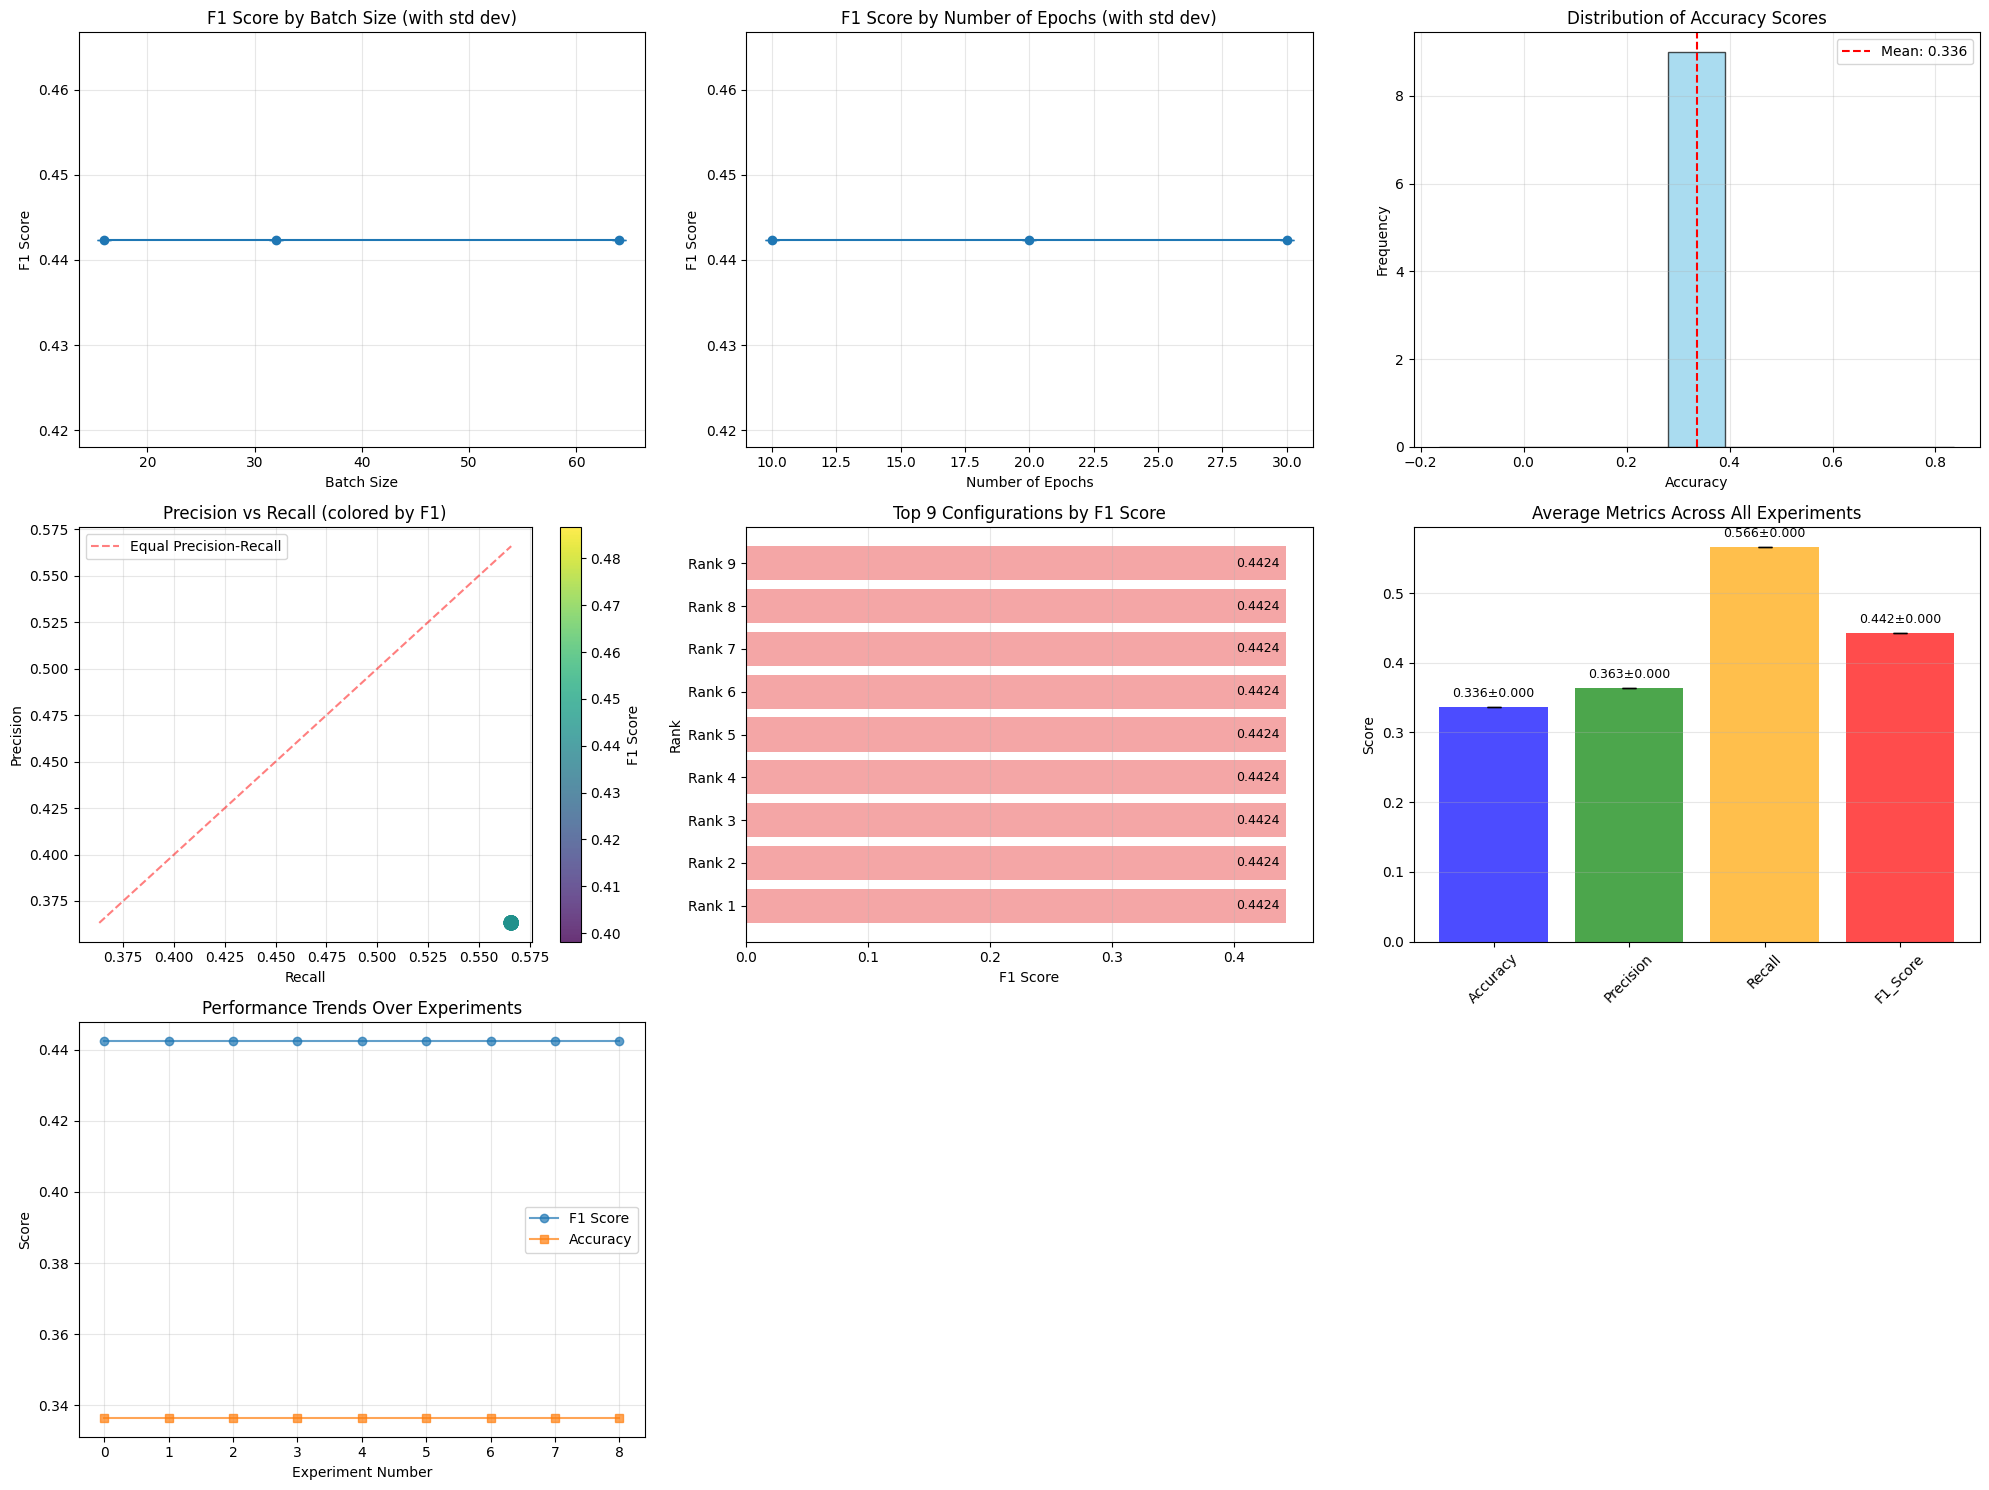

Comprehensive visualizations saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250816_162112/analysis/comprehensive_analysis_20250817_152135.png

Statistical Analysis:

Performance by Batch Size:
           Accuracy                      Precision                       \
               mean  std     min     max      mean  std     min     max   
Batch_size                                                                
16           0.3364  0.0  0.3364  0.3364    0.3632  0.0  0.3632  0.3632   
32           0.3364  0.0  0.3364  0.3364    0.3632  0.0  0.3632  0.3632   
64           0.3364  0.0  0.3364  0.3364    0.3632  0.0  0.3632  0.3632   

            Recall                      F1_Score                       
              mean  std     min     max     mean  std     min     max  
Batch_size                                                             
16          0.5659  0.0  0.5659  0.5659   0.4424  0.0  0.4424  0.4424  
32          0.5659  0.0 

In [7]:
# Analyze and visualize results with automatic Drive saving

def create_comprehensive_analysis():
    """Create comprehensive analysis and save all outputs to Drive"""

    # Load the most recent results
    if os.path.exists(RESULTS_FILE):
        results_df = pd.read_csv(RESULTS_FILE)
        print(f"Loaded results: {len(results_df)} completed experiments")
    else:
        print("No results file found. Please run experiments first.")
        return

    # Analysis directory
    analysis_dir = f"{SESSION_DRIVE_PATH}/analysis"
    os.makedirs(analysis_dir, exist_ok=True)

    # Check completion status
    total_experiments = len(experiment_configs)
    completed_experiments = len(results_df)
    completion_percentage = (completed_experiments / total_experiments) * 100

    analysis_summary = {
        'total_experiments': total_experiments,
        'completed_experiments': completed_experiments,
        'completion_percentage': completion_percentage,
        'analysis_date': datetime.now().isoformat()
    }

    print(f"\nEXPERIMENT STATUS:")
    print(f"   Total experiments: {total_experiments}")
    print(f"   Completed experiments: {completed_experiments}")
    print(f"   Completion: {completion_percentage:.1f}%")

    if completed_experiments < total_experiments:
        print(f"Analysis based on {completed_experiments} completed experiments")
    else:
        print(f"All experiments completed!")

    print("\nAnalyzing available results...")

    # Save detailed results table
    detailed_results_file = f"{analysis_dir}/detailed_results.csv"
    results_df.round(4).to_csv(detailed_results_file, index=False)
    print(f"Detailed results saved to: {detailed_results_file}")

    # Find best performing configuration
    if len(results_df) > 0:
        best_config = results_df.loc[results_df['F1_Score'].idxmax()]

        best_config_info = {
            'batch_size': int(best_config['Batch_size']),
            'learning_rate': float(best_config['Learning_rate']),
            'num_epochs': int(best_config['Num_epochs']),
            'f1_score': float(best_config['F1_Score']),
            'accuracy': float(best_config['Accuracy']),
            'precision': float(best_config['Precision']),
            'recall': float(best_config['Recall'])
        }

        analysis_summary['best_config'] = best_config_info

        print(f"\nBest performing configuration:")
        print(f"   Batch Size: {best_config_info['batch_size']}")
        print(f"   Learning Rate: {best_config_info['learning_rate']}")
        print(f"   Epochs: {best_config_info['num_epochs']}")
        print(f"   F1 Score: {best_config_info['f1_score']:.4f}")
        print(f"   Accuracy: {best_config_info['accuracy']:.4f}")
        print(f"   Precision: {best_config_info['precision']:.4f}")
        print(f"   Recall: {best_config_info['recall']:.4f}")

        # Create comprehensive visualizations
        fig_size = (20, 15)
        plt.figure(figsize=fig_size)

        # Plot 1: F1 Score vs Batch Size
        plt.subplot(3, 3, 1)
        if len(results_df['Batch_size'].unique()) > 1:
            batch_size_f1 = results_df.groupby('Batch_size')['F1_Score'].agg(['mean', 'std']).reset_index()
            plt.errorbar(batch_size_f1['Batch_size'], batch_size_f1['mean'],
                        yerr=batch_size_f1['std'], marker='o', capsize=5)
            plt.title('F1 Score by Batch Size (with std dev)')
            plt.xlabel('Batch Size')
            plt.ylabel('F1 Score')
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'Need more batch sizes\nfor comparison',
                    ha='center', va='center', transform=plt.gca().transAxes)
            plt.title('F1 Score by Batch Size')


        # Plot 2: F1 Score vs Epochs
        plt.subplot(3, 3, 2)
        if len(results_df['Num_epochs'].unique()) > 1:
            epochs_f1 = results_df.groupby('Num_epochs')['F1_Score'].agg(['mean', 'std']).reset_index()
            plt.errorbar(epochs_f1['Num_epochs'], epochs_f1['mean'],
                        yerr=epochs_f1['std'], marker='o', capsize=5)
            plt.title('F1 Score by Number of Epochs (with std dev)')
            plt.xlabel('Number of Epochs')
            plt.ylabel('F1 Score')
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'Need more epoch values\nfor comparison',
                    ha='center', va='center', transform=plt.gca().transAxes)
            plt.title('F1 Score by Epochs')

        # Plot 3: Accuracy Distribution
        plt.subplot(3, 3, 3)
        plt.hist(results_df['Accuracy'], bins=min(15, len(results_df)),
                alpha=0.7, edgecolor='black', color='skyblue')
        plt.axvline(results_df['Accuracy'].mean(), color='red', linestyle='--',
                   label=f'Mean: {results_df["Accuracy"].mean():.3f}')
        plt.title('Distribution of Accuracy Scores')
        plt.xlabel('Accuracy')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 4: Precision vs Recall
        plt.subplot(3, 3, 4)
        scatter = plt.scatter(results_df['Recall'], results_df['Precision'],
                             c=results_df['F1_Score'], cmap='viridis', alpha=0.8, s=100)
        plt.colorbar(scatter, label='F1 Score')
        plt.title('Precision vs Recall (colored by F1)')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.grid(True, alpha=0.3)

        # Add diagonal line for reference
        min_val = min(results_df['Recall'].min(), results_df['Precision'].min())
        max_val = max(results_df['Recall'].max(), results_df['Precision'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Equal Precision-Recall')
        plt.legend()

        # Plot 5: Top configurations
        plt.subplot(3, 3, 5)
        top_n = min(10, len(results_df))
        top_configs = results_df.nlargest(top_n, 'F1_Score')

        y_pos = np.arange(len(top_configs))
        bars = plt.barh(y_pos, top_configs['F1_Score'], alpha=0.7, color='lightcoral')
        plt.yticks(y_pos, [f"Rank {i+1}" for i in range(len(top_configs))])
        plt.title(f'Top {top_n} Configurations by F1 Score')
        plt.xlabel('F1 Score')
        plt.ylabel('Rank')
        plt.grid(True, alpha=0.3, axis='x')

        # Add value labels on bars
        for i, bar in enumerate(bars):
            width = bar.get_width()
            plt.text(width - 0.005, bar.get_y() + bar.get_height()/2,
                    f'{width:.4f}', ha='right', va='center', fontsize=9)

        # Plot 6: Metrics Comparison
        plt.subplot(3, 3, 6)
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
        metric_means = [results_df[metric].mean() for metric in metrics]
        metric_stds = [results_df[metric].std() for metric in metrics]

        bars = plt.bar(metrics, metric_means, yerr=metric_stds, capsize=5,
                      alpha=0.7, color=['blue', 'green', 'orange', 'red'])
        plt.title('Average Metrics Across All Experiments')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar, mean, std in zip(bars, metric_means, metric_stds):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
                    f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=9)


        # Plot 7: Performance Trends
        plt.subplot(3, 3, 7)
        if len(results_df) > 1:
            # Sort by experiment order (assuming index represents chronological order)
            sorted_results = results_df.reset_index()
            plt.plot(sorted_results.index, sorted_results['F1_Score'],
                    marker='o', alpha=0.7, label='F1 Score')
            plt.plot(sorted_results.index, sorted_results['Accuracy'],
                    marker='s', alpha=0.7, label='Accuracy')
            plt.title('Performance Trends Over Experiments')
            plt.xlabel('Experiment Number')
            plt.ylabel('Score')
            plt.legend()
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'Need more experiments\nfor trend analysis',
                    ha='center', va='center', transform=plt.gca().transAxes)
            plt.title('Performance Trends')

        plt.tight_layout()

        # Save plots
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        plot_file = f'{analysis_dir}/comprehensive_analysis_{timestamp}.png'
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Comprehensive visualizations saved to: {plot_file}")

        # Statistical Analysis
        print(f"\nStatistical Analysis:")

        # Performance by batch size
        batch_stats = results_df.groupby('Batch_size')[['Accuracy', 'Precision', 'Recall', 'F1_Score']].agg(['mean', 'std', 'min', 'max'])
        print(f"\nPerformance by Batch Size:")
        print(batch_stats.round(4))

        batch_stats_file = f"{analysis_dir}/batch_size_statistics.csv"
        batch_stats.to_csv(batch_stats_file)

        # Convert MultiIndex DataFrame to JSON-serializable format
        batch_stats_dict = {}
        for batch_size in batch_stats.index:
            batch_stats_dict[str(batch_size)] = {}
            for metric in ['Accuracy', 'Precision', 'Recall', 'F1_Score']:
                batch_stats_dict[str(batch_size)][metric] = {
                    'mean': float(batch_stats.loc[batch_size, (metric, 'mean')]),
                    'std': float(batch_stats.loc[batch_size, (metric, 'std')]),
                    'min': float(batch_stats.loc[batch_size, (metric, 'min')]),
                    'max': float(batch_stats.loc[batch_size, (metric, 'max')])
                }
        analysis_summary['batch_size_stats'] = batch_stats_dict

        # Learning rate analysis
        lr_analysis = results_df.groupby('Learning_rate')[['Accuracy', 'Precision', 'Recall', 'F1_Score']].agg(['mean', 'std', 'min', 'max'])
        print(f"\nLearning Rate Analysis:")
        print(lr_analysis.round(4))

        lr_stats_file = f"{analysis_dir}/learning_rate_statistics.csv"
        lr_analysis.to_csv(lr_stats_file)

        # Convert MultiIndex DataFrame to JSON-serializable format
        lr_stats_dict = {}
        for lr in lr_analysis.index:
            lr_stats_dict[str(lr)] = {}
            for metric in ['Accuracy', 'Precision', 'Recall', 'F1_Score']:
                lr_stats_dict[str(lr)][metric] = {
                    'mean': float(lr_analysis.loc[lr, (metric, 'mean')]),
                    'std': float(lr_analysis.loc[lr, (metric, 'std')]),
                    'min': float(lr_analysis.loc[lr, (metric, 'min')]),
                    'max': float(lr_analysis.loc[lr, (metric, 'max')])
                }
        analysis_summary['learning_rate_stats'] = lr_stats_dict

        # Best configuration for each batch size
        print(f"\nBest configuration for each batch size:")
        best_by_batch = {}
        for batch_size in results_df['Batch_size'].unique():
            batch_data = results_df[results_df['Batch_size'] == batch_size]
            best_batch = batch_data.loc[batch_data['F1_Score'].idxmax()]
            best_info = {
                'learning_rate': float(best_batch['Learning_rate']),
                'num_epochs': int(best_batch['Num_epochs']),
                'f1_score': float(best_batch['F1_Score'])
            }
            best_by_batch[str(int(batch_size))] = best_info  # Convert key to string
            print(f"Batch Size {batch_size}: LR={best_info['learning_rate']}, "
                  f"Epochs={best_info['num_epochs']}, F1={best_info['f1_score']:.4f}")

        analysis_summary['best_by_batch_size'] = best_by_batch

        # Create summary table matching original format
        summary_table = results_df.copy()
        summary_table = summary_table.sort_values(['Batch_size', 'Learning_rate', 'Num_epochs'])
        summary_table = summary_table[['Batch_size', 'Learning_rate', 'Num_epochs', 'Num_folds',
                                      'Momentum', 'Dropout', 'Accuracy', 'Precision', 'Recall', 'F1_Score']]

        print(f"\nComplete Results Table:")
        print(summary_table.to_string(index=False, float_format='%.4f'))

        # Export summary table
        summary_file = f'{analysis_dir}/complete_results_table_{timestamp}.csv'
        summary_table.to_csv(summary_file, index=False)
        print(f"Complete results table saved to: {summary_file}")

        # Save analysis summary with proper JSON serialization
        analysis_file = f"{analysis_dir}/analysis_summary.json"
        with open(analysis_file, 'w') as f:
            json.dump(analysis_summary, f, indent=2, default=str)
        print(f"Analysis summary saved to: {analysis_file}")

    else:
        print("No results available for analysis.")

    return analysis_summary

# Run comprehensive analysis
analysis_summary = create_comprehensive_analysis()

In [ ]:
# Train and save the best performing model to Google Drive

def train_and_save_best_model():
    """Train the best model on full dataset and save to Google Drive"""

    if len(results_df) == 0:
        print("No experiment results found. Run experiments first.")
        return

    print("\nTraining and saving the best model...")

    # Get best configuration
    best_config = results_df.loc[results_df['F1_Score'].idxmax()]
    best_config_dict = {
        'batch_size': int(best_config['Batch_size']),
        'learning_rate': float(best_config['Learning_rate']),
        'num_epochs': int(best_config['Num_epochs'])
    }

    print(f"Best configuration: {best_config_dict}")

    # Create model directory
    models_dir = f"{SESSION_DRIVE_PATH}/final_models"
    os.makedirs(models_dir, exist_ok=True)

    # Train final model on full dataset
    train_dataset = CyberbullyingDataset(comments, labels, tokenizer, PROJECT_CONFIG['max_length'])
    train_loader = DataLoader(train_dataset, batch_size=best_config_dict['batch_size'], shuffle=True)

    # Initialize best model
    final_model = ElectraMultiLabelClassifier(MODEL_NAME, len(label_columns))
    final_model.to(device)

    # Train final model
    optimizer = AdamW(final_model.parameters(), lr=best_config_dict['learning_rate'])
    total_steps = len(train_loader) * best_config_dict['num_epochs']
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    print("Training final model...")
    training_history = []

    for epoch in range(best_config_dict['num_epochs']):
        train_loss = train_epoch(final_model, train_loader, optimizer, scheduler, device)
        training_history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss
        })
        print(f"Epoch {epoch+1}/{best_config_dict['num_epochs']}, Loss: {train_loss:.4f}")

    # Save the model with comprehensive metadata
    model_info = {
        'model_name': PROJECT_CONFIG['model_name'],
        'model_path': PROJECT_CONFIG['model_path'],
        'config': best_config_dict,
        'tokenizer_name': MODEL_NAME,
        'label_columns': label_columns,
        'training_history': training_history,
        'best_metrics': {
            'accuracy': float(best_config['Accuracy']),
            'precision': float(best_config['Precision']),
            'recall': float(best_config['Recall']),
            'f1_score': float(best_config['F1_Score'])
        },
        'dataset_info': {
            'num_samples': len(comments),
            'num_labels': len(label_columns),
            'max_length': PROJECT_CONFIG['max_length']
        },
        'training_date': datetime.now().isoformat(),
        'session_id': SESSION_ID
    }

    # Save model
    model_filename = f'best_{PROJECT_CONFIG["model_name"]}_cyberbullying_model.pth'
    model_path = f"{models_dir}/{model_filename}"

    torch.save({
        'model_state_dict': final_model.state_dict(),
        'model_info': model_info
    }, model_path)

    # Save model info separately
    info_path = f"{models_dir}/model_info.json"
    with open(info_path, 'w') as f:
        json.dump(model_info, f, indent=2, default=str)

    print(f"Best model saved to: {model_path}")
    print(f"Model info saved to: {info_path}")

    # Save tokenizer
    tokenizer_path = f"{models_dir}/tokenizer"
    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to: {tokenizer_path}")

    return final_model, model_info

# Train and save best model
final_model, model_info = train_and_save_best_model()


Training and saving the best model...
Best configuration: {'batch_size': 32, 'learning_rate': 0.01, 'num_epochs': 30}
Training final model...


Training: 100%|██████████| 393/393 [00:44<00:00,  8.90it/s, loss=0.222]


Epoch 1/30, Loss: 0.4349


Training: 100%|██████████| 393/393 [00:44<00:00,  8.88it/s, loss=0.454]


Epoch 2/30, Loss: 0.4303


...

Epoch 28/30, Loss: 0.4265


Training: 100%|██████████| 393/393 [00:44<00:00,  8.86it/s, loss=0.485]


Epoch 29/30, Loss: 0.4264


Training: 100%|██████████| 393/393 [00:44<00:00,  8.76it/s, loss=0.55]


Epoch 30/30, Loss: 0.4265
Best model saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250814_172322/final_models/best_bangla-electra_cyberbullying_model.pth
Model info saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250814_172322/final_models/model_info.json
Tokenizer saved to: /content/drive/MyDrive/Bangla-ELECTRA-Cyberbullying/experiments/bangla-electra_20250814_172322/final_models/tokenizer
